In this workshop we would like to fit a very simple neural network in python, and in doing so show that neural networks can easily learn non-linear relationships between x and y.

We will also see how individual neurons specialise in solving different aspects of prediction the problem

This example uses python code to train the neural network to a simple toy example - this is much more trivival than anything we would see in a real world application, but it helps to give us some intuition about how neural networks work.

I will describe elements of the python code as we step through the example - but don't worry if you are not understanding every detail. The idea is understand the basic ideas, and the end result.

To begin, please run the code in the cell below by clicking on it to highlight the cell and pressing Shift+Enter, or click the 'play' button next to the cell.

In [19]:
!git clone https://github.com/jasonhilton/circle_NN_example.git
%cd circle_NN_example

D:\pycharm_projects\circle_NN_example\circle_nn_example


Cloning into 'circle_nn_example'...


First we must load in some python libraries.
Python libraries are pre-written python programs that are designed to do specific tasks.
We use keras, a high-level python library, to fit our neural network model. The pandas library allows us to work with tabular data. The plotnine library allows us to make nice plots (it is based on the similar R library ggplot2)!

As you work through the document, when you see a code cell, click on the 'play' button that appears as you hover over the cell to run it.

In [1]:
import os
from xml.dom.expatbuilder import theDOMImplementation

os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
import pandas as pd
from plotnine import *
from keras import models
from keras import layers

We have some pre-prepared data stored in a python file called circle_data.py. We can import this data and plot it.

In [2]:
from circle_data import circle_df

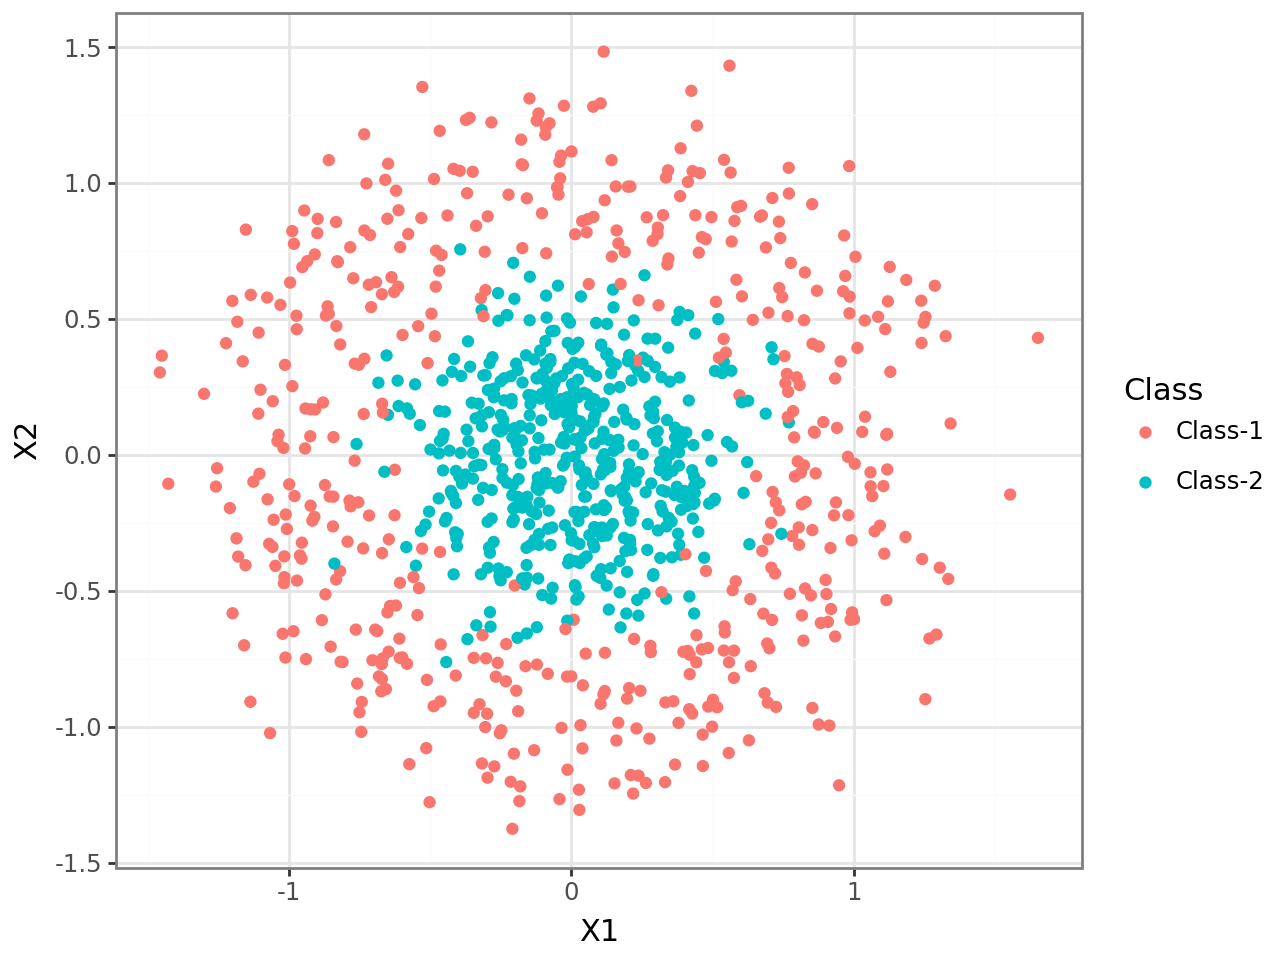

In [3]:
(ggplot(circle_df, aes(x="X1", y="X2", colour="Class")) + geom_point() +
  theme_bw())


As you can see, we have a dataset containing two classes (red and blue above) and we have two covariates, $x_1$ and $x_2$.

We can easily see that there is a pattern to the data. Imagining two concentric circles centred on the middle of the plot, the inner circle contains mainly the blue class, while the outer circle contains mainly the red class.

However, this pattern is not easy for traditional statistical models to learn, since we can't draw a single straight line that separates the classes.

With some simple trigonometry, we could transform this data into a form where we could use more traditional methods to predict classes. But neural network models are able to learn how to predict these classes without any external information about how the data are organised, simply by allow non-linear neurons to specialise.

We will now fit a simple neural network to this data.

Keras allows us to build up neural network models layer by layer, using the `Sequential` class.

In [4]:
circle_model = models.Sequential()

We will start by adding an input layer that describes the shape of single observation.
Since we have two dimensional input (x1, x2) we specify this.

In [5]:
circle_model.add(layers.Input(shape=(2,)))

Next, lets add a dense layer of size 8, with a rectified linear activation function (a **RE**ctified **L**inear **U**nit).
A dense layer is a layer where all units are completely connected to all outputs in the preceding layer

In [6]:
circle_model.add(layers.Dense(8, activation="relu"))

Next, we are going to add layer with a single unit. We wouldn't normally do this, but in our toy case, but it helps us see how our neural network is learning.

In [7]:
circle_model.add(layers.Dense(1))

Finally, we will an output layer that converts that layer to the $[0,1]$ interval using a sigmoid function (also know as a logit). This ensures the output of the network can be interpreted as the probability that an observation belongs to the red class - with one indicating that it is certain, and zero indicating that it is impossible.

In [8]:
circle_model.add(layers.Dense(1, activation="sigmoid"))

In [9]:
circle_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35 (140.00 B)

 Trainable params: 35 (140.00 B)

 Non-trainable params: 0 (0.00 B)

Before we can fit our model, we need to compile it - that is, turn it from our python code into an ready-to-run program that can be executed efficiently. There are a few technical details that we will skip over about how exactly we want the optimiser to find the values of the parameter that minimise the error on the training dataset - but don't worry about these for now.

In [10]:
circle_model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

As always, we need to split our data into training and testing sets. This has been done for us in the circle_data.py file - all we need to do is import it. 80% of the data is used in training, 20% for testing.

In [11]:
from circle_data import circle_test, circle_train

Now we are ready to fit our model. Again, keras has built in functionality to allows us to do this. To do this we specify the covariates X1 and X2 and the outcome variable Y we want to use from the training data. We don't need to worry about the details of how this works at this stage.

In [12]:
history = circle_model.fit(circle_train.loc[:,["X1", "X2"]], circle_train.loc[:,"Y"],
                           epochs=100, batch_size=64)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4988 - loss: 0.6828  
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5188 - loss: 0.6755 
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5475 - loss: 0.6692 
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5688 - loss: 0.6630 
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5987 - loss: 0.6566 
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6200 - loss: 0.6503 
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6538 - loss: 0.6440 
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6750 - loss: 0.6376 
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6975 - loss: 0.6310 
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7300 - loss: 0.6241 
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7400 - loss: 0.6172 
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

The model performs well during the training phase, obtaining ~95% accuracy.

Keras allows us to evaluate the model against the test data. This test indicates that the model performance doesn't seem to be a case of overfitting.

In [13]:
circle_model.evaluate(circle_test.loc[:,["X1", "X2"]], circle_test.loc[:,"Y"])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9700 - loss: 0.1259 


[0.12593694031238556, 0.9700000286102295]

The model seems to have learnt the non-linear relationship between $X$ and $y$ well. But what is happening 'underneath the hood'?

We can examine the results on each of the 8 neurons in the hidden layer to see *how* the network has learnt the nonlinear relationship between the X and Y variables.

With a bit of python code, we can extract the outputs from each of the 8 neurons in the hidden layer, evaluated at the test data points. Don't worry about the details of the below code.

In [14]:
feature_only_model = keras.models.Model(circle_model.inputs, circle_model.layers[-3].output)

In [15]:
hidden_layer_output = feature_only_model.predict(circle_test.loc[:,["X1", "X2"]])
hl_out_df = pd.DataFrame(hidden_layer_output, columns=["Z" + str(i) for i in range(8)])
hl_out_df= pd.concat([hl_out_df, circle_test.reset_index()],  axis=1)
hl_out_df=pd.wide_to_long(hl_out_df[["index","Z0", "Z1", "Z2", "Z3", "Z4", "Z5", "Z6", "Z7", 'X1',"X2"]], ["Z"],i="index", j="hidden_neuron")
hl_out_df =hl_out_df.reset_index()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


We can plot the output of each neuron separately in a different subplot, to see how each neuron specialise on separate area of the input space.

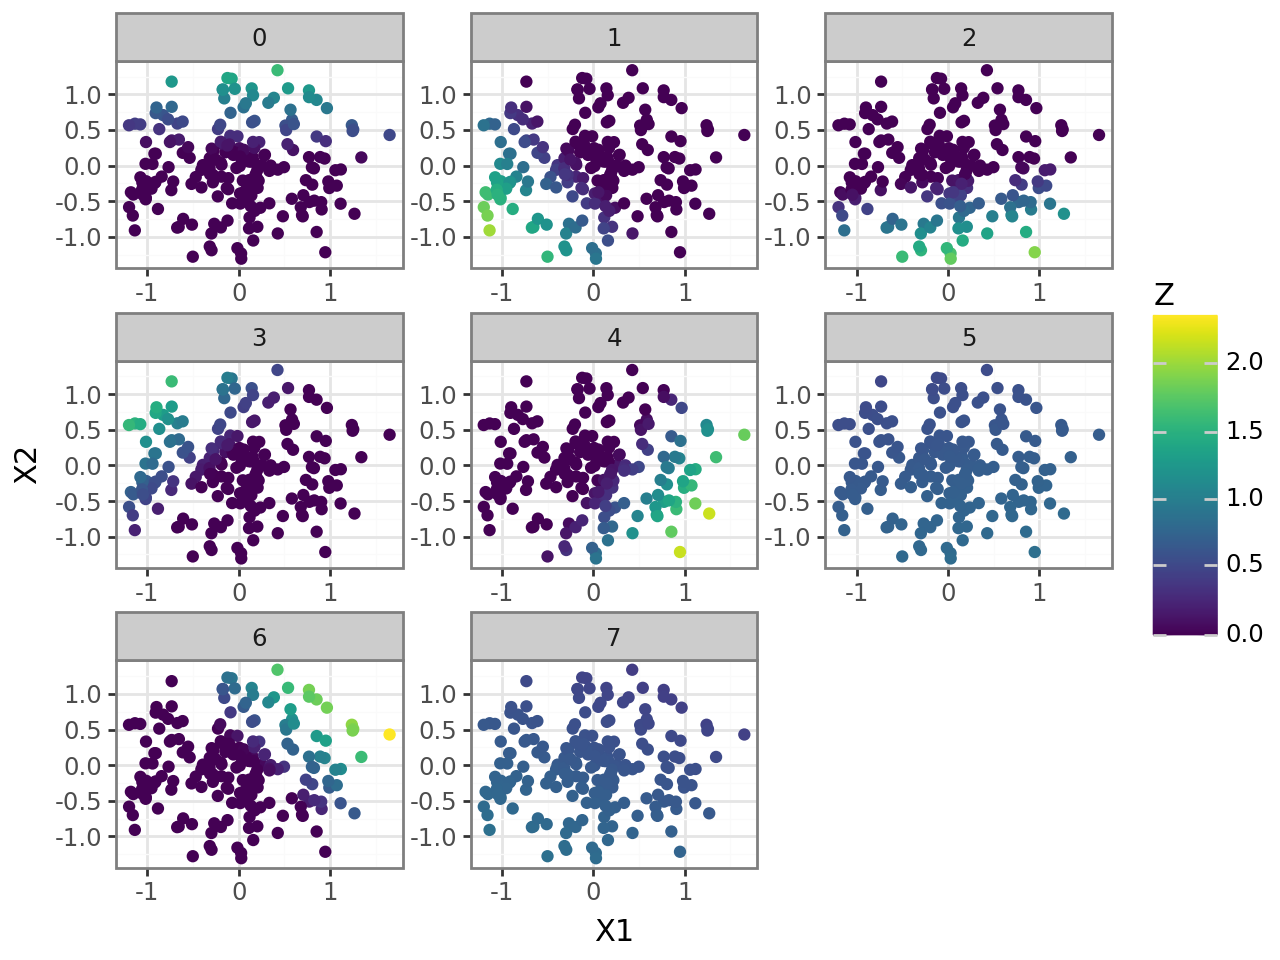

In [16]:
(ggplot(hl_out_df, aes(x="X1", y="X2", colour="Z")) + geom_point() + facet_wrap("~hidden_neuron", scales="free") + theme_bw())


Imagine combining all 8 of the neurons by summing their values. This would give us a single output, that would enables us to distinguish between the class. It should give different values to observations further away from the centre of the circle.

And this is exactly what happens! In fact we can see this directly in the model predictions.

In [17]:
circle_test["Y_hat"]=circle_model.predict(circle_test.loc[:,["X1", "X2"]])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


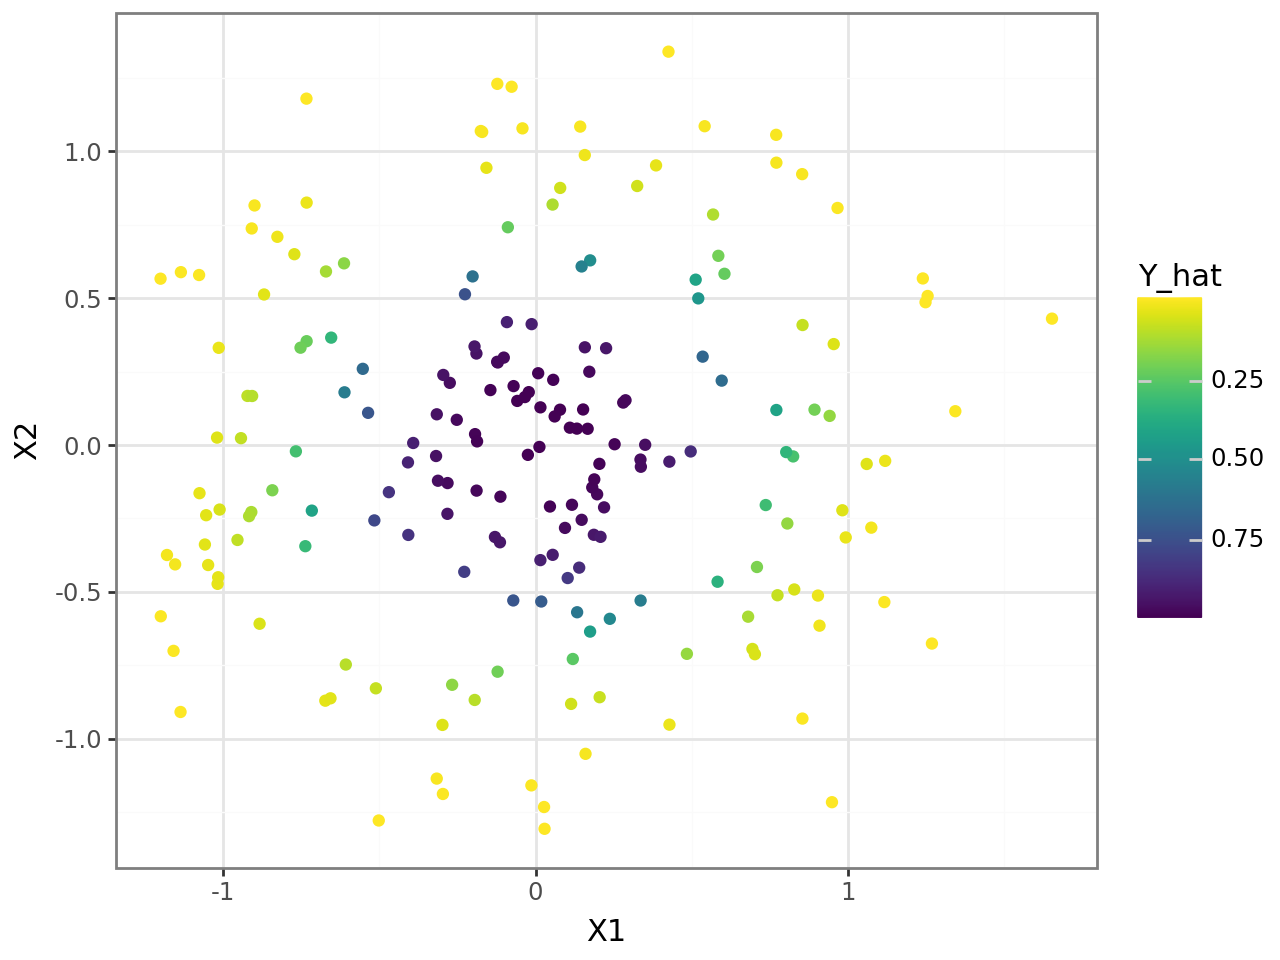

In [18]:
(ggplot(circle_test,aes(x="X1", y="X2", colour="Y_hat")) + geom_point() + theme_bw() +
    scale_colour_continuous(trans='reverse'))


We have seen how neural networks can specialise on specific tasks, and how when combined, they can learn arbitrary relationships between covariates and outcomes.
This particular example is trivial, but it demonstrates part of why neural networks are so powerful!